# Notebook 04: Default XGBoost Baseline

This notebook opens the boosting branch of the project. It follows the early baseline and model-family exploration stages, then establishes the initial XGBoost reference point for the later tuning sequence.


Experiment 1: Default XGBoost parameters

1. Load data...
Train shape: (700000, 26)

2. Prepare data...
Encoded feature count: 42
Train set: (560000, 42), Validation set: (140000, 42)

3. Baseline Decision Tree AUC: 0.6825

4. Train the default XGBoost model...

5. Model evaluation...

Default XGBoost AUC: 0.7192
Improvement over baseline: +0.0367

Classification report:
              precision    recall  f1-score   support

         0.0       0.62      0.39      0.48     52739
         1.0       0.70      0.85      0.77     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.62      0.62    140000
weighted avg       0.67      0.68      0.66    140000


6. Plot learning curves...


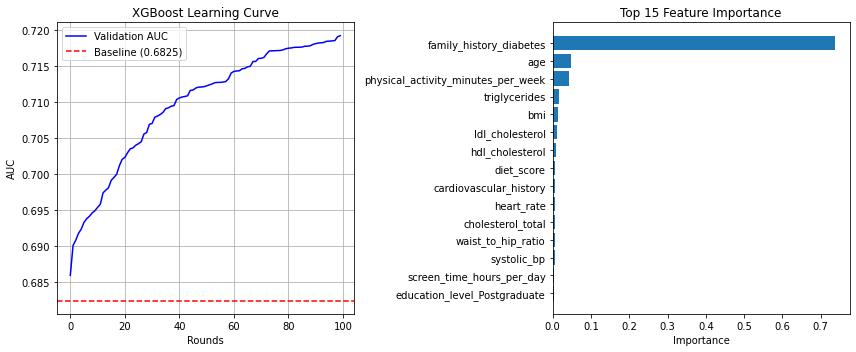


Top 10 most important features:
                            feature  importance
            family_history_diabetes    0.738619
                                age    0.048537
 physical_activity_minutes_per_week    0.042958
                      triglycerides    0.015972
                                bmi    0.013689
                    ldl_cholesterol    0.012135
                    hdl_cholesterol    0.007669
                         diet_score    0.007241
             cardiovascular_history    0.006900
                         heart_rate    0.006130

7. Save model...
Model saved to ../models/xgboost_default.pkl

8. Generate Kaggle submission file...
Submission file saved to ../submissions/xgboost_default.csv


In [1]:
# 04_xgboost_default.ipynb

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("Experiment 1: Default XGBoost parameters") 
print("="*60)

# 1. Load data
print("\n1. Load data...") 
train = pd.read_csv('../data/train.csv')
print(f"Train shape: {train.shape}") 

# 2. Prepare data(same as the baseline model to ensure a fair comparison)
print("\n2. Prepare data...") 
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

categorical_cols = ['gender', 'ethnicity', 'education_level', 
                   'income_level', 'smoking_status', 'employment_status']
X_encoded = pd.get_dummies(X, columns=categorical_cols)
print(f"Encoded feature count: {X_encoded.shape[1]}") 

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}") 

# 3. Baseline results(manually recorded)
baseline_auc = 0.6825
print(f"\n3. Baseline Decision Tree AUC: {baseline_auc}") 

# 4. Default XGBoost parameters
print("\n4. Train the default XGBoost model...") 
xgb_default = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    use_label_encoder=False
)

xgb_default.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 5. Evaluation
print("\n5. Model evaluation...") 
y_pred_proba = xgb_default.predict_proba(X_val)[:, 1]
y_pred = xgb_default.predict(X_val)

current_auc = roc_auc_score(y_val, y_pred_proba)
print(f"\nDefault XGBoost AUC: {current_auc:.4f}") 
print(f"Improvement over baseline: +{current_auc - baseline_auc:.4f}") 

print("\nClassification report:") 
print(classification_report(y_val, y_pred))

# 6. Learning curves
print("\n6. Plot learning curves...") 
results = xgb_default.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_axis, results['validation_0']['auc'], 'b-', label='Validation AUC')
plt.axhline(y=baseline_auc, color='r', linestyle='--', label=f'Baseline ({baseline_auc})')
plt.xlabel('Rounds')
plt.ylabel('AUC')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.grid(True)

# 7. Feature importance
plt.subplot(1, 2, 2)
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_default.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 10 most important features:") 
print(importance.head(10).to_string(index=False))

# 8. Save model
print("\n7. Save model...") 
joblib.dump(xgb_default, '../models/xgboost_default.pkl')
print("Model saved to ../models/xgboost_default.pkl") 

# 9. Generate submission file(optional)
print("\n8. Generate Kaggle submission file...") 
test = pd.read_csv('../data/test.csv')
X_test = test.drop(['id'], axis=1)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

missing_cols = set(X_train.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train.columns]

test_pred = xgb_default.predict_proba(X_test_encoded)[:, 1]

submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': test_pred
})
submission.to_csv('../submissions/xgboost_default.csv', index=False)
print("Submission file saved to ../submissions/xgboost_default.csv") 


# Experiment 4 Summary: Default XGBoost in the Boosting Comparison Track

## Role in the series
This notebook establishes the first XGBoost baseline after the earlier non-boosting exploration in Notebook 03. Its main value is to anchor the boosting branch with a simple, reproducible starting point.

## Comparison framing
Together with Notebook `04.5_lightgbm_default`, this notebook forms the default boosting comparison layer:
- Notebook 04 focuses on the default XGBoost baseline.
- Notebook 04.5 mirrors the setup with a default LightGBM baseline.

## Main takeaway
The default XGBoost result is already strong enough to justify a longer boosting-focused search. It is not the project's final answer, but it becomes the benchmark against which later tuning decisions are interpreted.

## Reproducibility note
The notebook filename now matches the current series numbering. The executable cell remains the original default-XGBoost baseline run used for this stage of the project.
